Environment: the `etunc` kernel (`envs/etunc.yml`, with the repo installed editable).

# Sensitivity of CMIP6 binned ET to regridding resolution

`scripts/bin_cmip.py` processes each model in this order:

1. Annual means on the **native grid**, masked by native land fraction (sftlf > 0.5, no Greenland/Iceland).
2. **Conservative regridding** of the annual means to 1° (`na_thres = 0.5`), then the Natural Earth land
   mask and a common area mask (cells valid in every model).
3. Climatological LAI and AI **on the target grid** (AI = clim Rn / clim L·P).
4. **Quantile edges pooled across models**: each model contributes its member-mean LAI and AI once; cells are
   not area-weighted.
5. **Binning**: every (year, gridcell) ET sample goes to the bin of its gridcell's climatological LAI and AI.

This notebook repeats steps 1–5 at 0.25°, 0.5°, 1° and 2°. It also runs them on each model's native grid
with step 2 skipped, in two versions: **native** uses only the native sftlf mask, and **native + NE** adds the
Natural Earth land mask, as on the regridded grids. The three models span a range of native resolutions:

| model | native grid (lat × lon) | spacing |
|---|---|---|
| EC-Earth3-Veg | 256 × 512 | ~0.7° (high) |
| CESM2 | 192 × 288 | 0.94° × 1.25° (medium) |
| CanESM5 | 64 × 128 | ~2.8° (low) |

**What to expect**
- *Finer than native*: no new information. Interior values are copies of the native cells. Coastal cells
  still change, through `na_thres` and the Natural Earth mask.
- *Coarser than native*: LAI and AI are smoothed, so their distributions narrow and the pooled quantile edges
  move inward.
- *Native*: the pooled edges count cells, not area, so EC-Earth3-Veg (~16× as many cells as CanESM5) dominates them.
- Bin means are compared **by quantile bin index**. The physical LAI/AI range of a bin changes with resolution.

**Separating the effects**: every regridded grid is also binned with the native + NE pooled edges ("fixed
edges"). This splits each difference from native into a *sample effect* (the samples changed) and an *edge
effect* (the pooled edges moved).

**Choices**: one member per model (`cbe.DEFAULT_MEMBERS = "top"`). Native case: each model uses its own
sftlf mask and valid area (no common area, since the grids differ). Pooled edges are unweighted, as in the
script. Figures are shown inline only; nothing is written to disk.

In [1]:
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

import etunc.config as config
import etunc.temporal as temporal
import etunc.grid as rg
import etunc.binning as binning
import etunc.plotting as plotting
import etunc.load.cmip as cmip
from etunc.load.cmip import CMIPESGFLoader

warnings.filterwarnings("ignore", message="Input array is not C_CONTIGUOUS", category=UserWarning)

In [2]:
SOURCE_IDS = ["EC-Earth3-Veg", "CESM2", "CanESM5"]  # high, medium, low native resolution
# "native": no regridding, native sftlf mask only
# "native_ne": no regridding, native sftlf mask and the Natural Earth land mask (as on the regridded grids)
RESOLUTIONS = ["native", "native_ne", 0.25, 0.5, 1.0, 2.0]
NATIVE = ["native", "native_ne"]
REGRIDDED = [res for res in RESOLUTIONS if res not in NATIVE]

# Everything else as in scripts/bin_cmip.py (copied from its settings)
EXPERIMENT_ID = "historical"
VARIABLES = ["evspsbl", "lai", "pr", "rsds", "rsus", "rlds", "rlus"]
TIME_SLICE = slice("1995-01", "2014-12")
N_BINS = {"lai": 15, "ai": 15}
NA_THRES = 0.5
PERIOD = temporal.format_time_period(TIME_SLICE)

LABELS = {"native": "native", "native_ne": "native + NE", **{res: f"{res:g}°" for res in REGRIDDED}}
REF = LABELS["native_ne"]  # its pooled edges are the fixed edges for the regridded grids
COLORS = {sid: f"C{i}" for i, sid in enumerate(SOURCE_IDS)}  # same model colors in every figure
R_EARTH_KM = 6371.0

## Target grids and regridder

`rg.target_grid(res)` builds the global grid for any spacing that divides 180 (here 0.25° and 2° as well as
the standard 0.5° and 1°), and `cmip.regrid_annual` regrids onto it with `rg.bounded_conservative_regridder`,
exactly as `scripts/bin_cmip.py` does for its 1° grid.

## Load native annual means

`cmip.load_native` is the first half of `cmip.load_model`, up to the regridding step. Native annual means are loaded once
per model and reused for every resolution.

In [4]:
loader = CMIPESGFLoader(config.CMIP_CATALOG)
avail = cmip.available_members(loader.catalog, VARIABLES, EXPERIMENT_ID)
sftlf = cmip.sftlf_files(config.CMIP_FX_CATALOG)
members = {sid: cmip.select_members(sid, avail[sid]) for sid in SOURCE_IDS}

# Annual means (member, year, lat, lon) of ET, LAI, pr, Rn on the native grid, masked by native sftlf,
# with the native land mask and the native grid with cell edges
native = {}
for sid in SOURCE_IDS:
    native[sid] = cmip.load_native(loader, sid, members[sid], sftlf[sid], VARIABLES, EXPERIMENT_ID, TIME_SLICE)
    ann, _, src_grid = native[sid]
    dlat, dlon = rg.approx_resolution(src_grid)
    print(f"{sid:14}: {members[sid]}, native {src_grid.sizes['lat']}x{src_grid.sizes['lon']} "
          f"(~{dlat:.2f}° x {dlon:.2f}°), years {temporal.period_str(ann['et'].year.values)}")

EC-Earth3-Veg : ['r1i1p1f1'], native 256x512 (~0.70° x 0.70°), years 199501-201412


/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'sftlf' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


CESM2         : ['r1i1p1f1'], native 192x288 (~0.94° x 1.25°), years 199501-201412
CanESM5       : ['r1i1p1f1'], native 64x128 (~2.79° x 2.81°), years 199501-201412


## Run the pipeline at each resolution

`run_pipeline` follows `main()` of `scripts/bin_cmip.py`:
- annual means: regridded (`cmip.regrid_annual`, the second half of `cmip.load_model`), or native for `"native"` / `"native_ne"`
- `binning.prepare_inputs`
- area mask
- pooled edges
- per-member binning, then `binning.pool_members`

Each model's own edges (pooled over its members) are kept for the edge plots, as in the script. Only the
pooled edges are used for binning.

In [5]:
def concat_models(das: list[xr.DataArray], sids: list[str]) -> xr.DataArray:
    # As in scripts/bin_cmip.py
    return xr.concat(
        das, dim="source_id", coords="different", compat="equals", join="exact", combine_attrs="drop_conflicts",
    ).assign_coords(source_id=sids)


def bin_models(inputs: dict, edges: dict, label: str) -> xr.DataArray:
    # Per-member bin statistics with `edges`, members pooled per model, concatenated along source_id
    bs = []
    for sid in SOURCE_IDS:
        bs_m = binning.bin_stats(
            inputs[sid]["et"], inputs[sid]["lai"], inputs[sid]["ai"], edges["lai"], edges["ai"],
            member_dim="member", y_name="lai", x_name="ai", name="evspsbl",
            attrs={"source_id": sid, "time_period": PERIOD, "grid": label},
        )
        bs.append(binning.pool_members(bs_m))
    return concat_models(bs, SOURCE_IDS)


def run_pipeline(res) -> dict:
    # Annual means for every model on this resolution's grid(s), plus the land mask(s)
    if res in NATIVE:
        anns = {sid: {k: a.sel(lat=config.LAT_BNDS) for k, a in native[sid][0].items()} for sid in SOURCE_IDS}
        masks = {sid: native[sid][1].sel(lat=config.LAT_BNDS) for sid in SOURCE_IDS}
        if res == "native_ne":
            # Natural Earth land (no Greenland/Iceland) evaluated on each native grid
            masks = {sid: m & rg.land_mask(m) for sid, m in masks.items()}
    else:
        mask = rg.land_mask(rg.target_grid(res)).sel(lat=config.LAT_BNDS)  # Natural Earth, no Greenland/Iceland
        anns = {sid: cmip.regrid_annual(native[sid][0], native[sid][2], res, mask, NA_THRES) for sid in SOURCE_IDS}
        masks = {sid: mask for sid in SOURCE_IDS}
    for sid in SOURCE_IDS:
        for k in anns[sid]:
            anns[sid][k] = anns[sid][k].assign_coords(member_id=("member", members[sid]))

    # Binning inputs: annual ET (member, year, lat, lon), climatological LAI and AI (member, lat, lon)
    inputs = {
        sid: binning.prepare_inputs(et=a["et"], lai=a["lai"], precip=a["pr"], rn=a["rn"], mask=masks[sid])
        for sid, a in anns.items()
    }

    # Area mask: common to all models on a shared grid, each model's own valid area on native grids
    if res in NATIVE:
        area = {sid: (masks[sid] == 1) & binning.valid_area(inputs[sid], member_dim="member") for sid in SOURCE_IDS}
    else:
        common = binning.common_area(inputs, masks[SOURCE_IDS[0]], member_dim="member")
        area = {sid: common for sid in SOURCE_IDS}
    with xr.set_options(keep_attrs=True):
        inputs = {sid: {k: da.where(area[sid]) for k, da in inp.items()} for sid, inp in inputs.items()}

    # Member-mean climatologies for the maps, over the binned area only
    clim = {
        sid: {
            "evspsbl": temporal.aggregate(inputs[sid]["et"], "clim"),
            "lai": inputs[sid]["lai"],
            "pr": temporal.aggregate(anns[sid]["pr"], "clim").where(area[sid]),
            "rn": temporal.aggregate(anns[sid]["rn"], "clim").where(area[sid]),
            "ai": inputs[sid]["ai"],
        }
        for sid in SOURCE_IDS
    }
    clim = {sid: {v: da.mean("member", keep_attrs=True) for v, da in c.items()} for sid, c in clim.items()}

    # Pooled edges: each model's member-mean field once (unweighted by cell count or area)
    edges, model_edges = {}, {}
    for v in ("lai", "ai"):
        attrs = {**binning.EDGE_ATTRS[v], "time_period": PERIOD, "grid": LABELS[res]}
        edges[v] = binning.pooled_bin_edges(
            {sid: inputs[sid][v].mean("member") for sid in SOURCE_IDS}, N_BINS[v], name=v, attrs=attrs, verbose=False,
        )
        model_edges[v] = {
            sid: binning.pooled_bin_edges(inputs[sid][v], N_BINS[v], name=v, attrs=attrs, verbose=False)
            for sid in SOURCE_IDS
        }

    bs = bin_models(inputs, edges, LABELS[res])
    return {"inputs": inputs, "clim": clim, "area": area, "edges": edges, "model_edges": model_edges, "bs": bs}


results = {}
for res in RESOLUTIONS:
    print(f"\n=== {LABELS[res]} ===")
    results[LABELS[res]] = run_pipeline(res)


=== native ===

=== native + NE ===

=== 0.25° ===
EC-Earth3-Veg   : 2.2662e+05 valid gridcells
CESM2           : 2.2614e+05 valid gridcells
CanESM5         : 2.1597e+05 valid gridcells
common area: 2.1101e+05 of 2.3434e+05 land gridcells

=== 0.5° ===
EC-Earth3-Veg   : 5.6721e+04 valid gridcells
CESM2           : 5.6541e+04 valid gridcells
CanESM5         : 5.4122e+04 valid gridcells
common area: 5.2896e+04 of 5.8648e+04 land gridcells

=== 1° ===
EC-Earth3-Veg   : 1.4155e+04 valid gridcells
CESM2           : 1.4192e+04 valid gridcells
CanESM5         : 1.3498e+04 valid gridcells
common area: 1.3196e+04 of 1.4661e+04 land gridcells

=== 2° ===
EC-Earth3-Veg   : 3.5300e+03 valid gridcells
CESM2           : 3.5390e+03 valid gridcells
CanESM5         : 3.3890e+03 valid gridcells
common area: 3.3420e+03 of 3.6760e+03 land gridcells


### Summary table

Binned area, sample counts and area-weighted means of each climatology over the binned area. Conservative
regridding should roughly preserve the area means. Departures come from the binned area changing with
resolution (coastlines, `na_thres`, the common area mask). Sample counts scale with the number of cells, so
they are not comparable across resolutions. Bin means are.

In [6]:
def cell_area(da: xr.DataArray) -> xr.DataArray:
    # Cell area [km2] from edges at midpoints between centers (works for Gaussian native grids too)
    lat_b = np.clip(rg.cell_edges(da.lat.values, name="lat"), -90, 90)
    lon_b = rg.cell_edges(da.lon.values, name="lon")
    dy = np.abs(np.diff(np.sin(np.deg2rad(lat_b))))
    dx = np.abs(np.deg2rad(np.diff(lon_b)))
    return xr.DataArray(R_EARTH_KM**2 * np.outer(dy, dx), coords={"lat": da.lat, "lon": da.lon}, dims=("lat", "lon"))


def area_mean(da: xr.DataArray) -> float:
    w = cell_area(da).where(da.notnull())
    return float((da * w).sum() / w.sum())


rows = []
for sid in SOURCE_IDS:
    for label, r in results.items():
        area = r["area"][sid]
        rows.append({
            "resolution": label,
            "source_id": sid,
            "gridcells": int(area.sum()),
            "area [Mkm2]": float(cell_area(area).where(area).sum()) / 1e6,
            "samples": int(r["bs"].sel(source_id=sid, stats="count").sum()),
            **{f"{v} mean": area_mean(r["clim"][sid][v]) for v in ("evspsbl", "lai", "pr", "rn")},
        })
summary = pd.DataFrame(rows).set_index(["source_id", "resolution"])
summary.style.format(precision=3)

## Diagnostics at each resolution

### Maps of the climatological fields

These are the member-mean climatologies over the area that gets binned. Each variable has one color scale
across all models and resolutions, set from the native fields. The AI scale stops at the 90th percentile,
because hyper-arid cells reach AI ~ 1000.

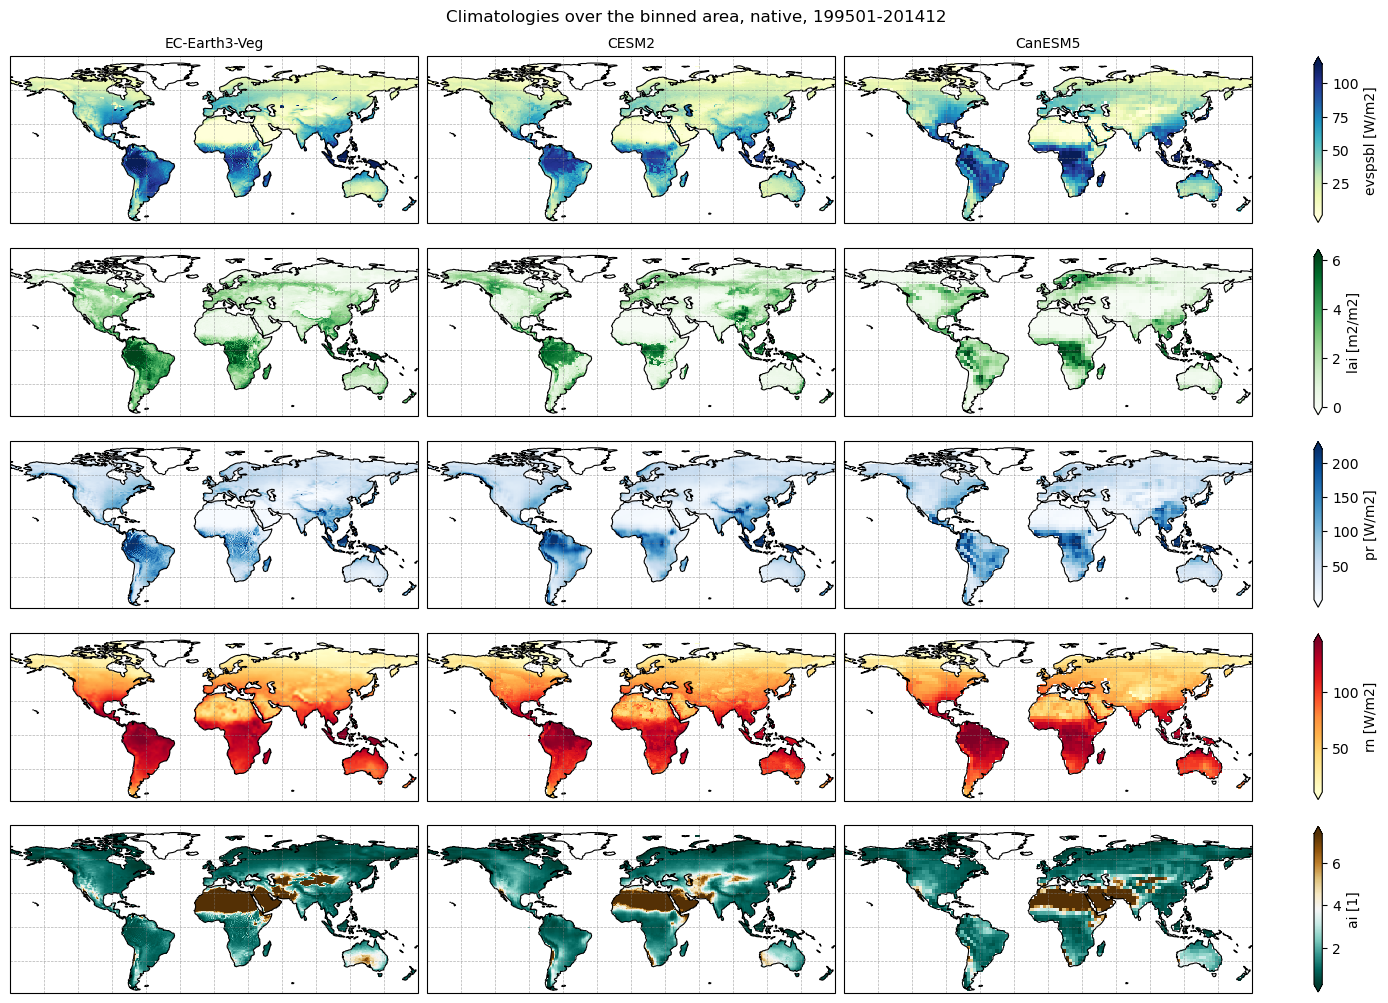

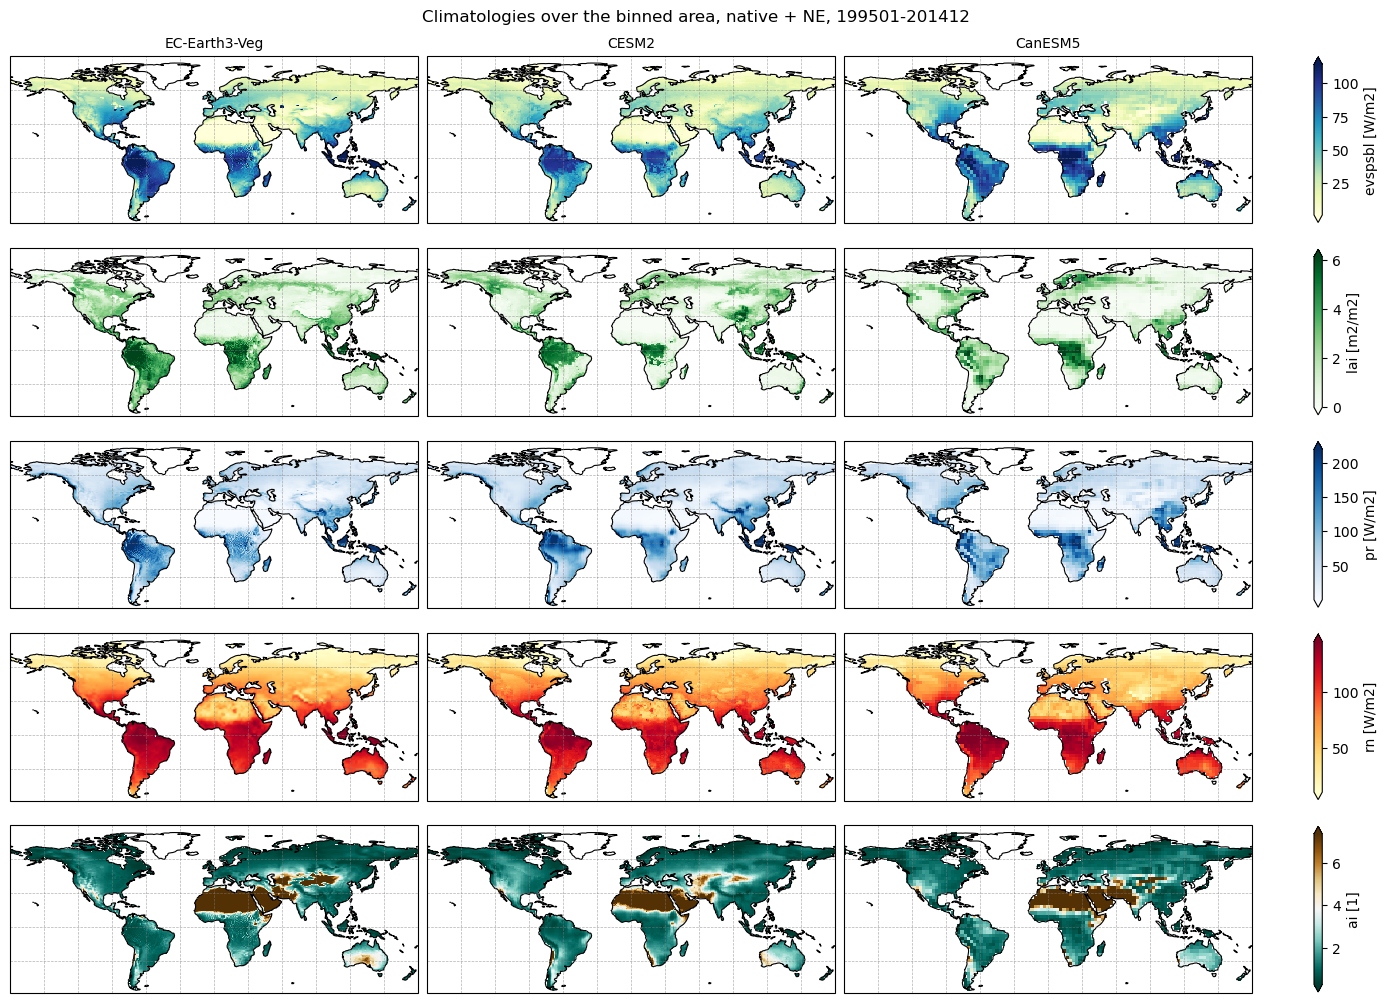

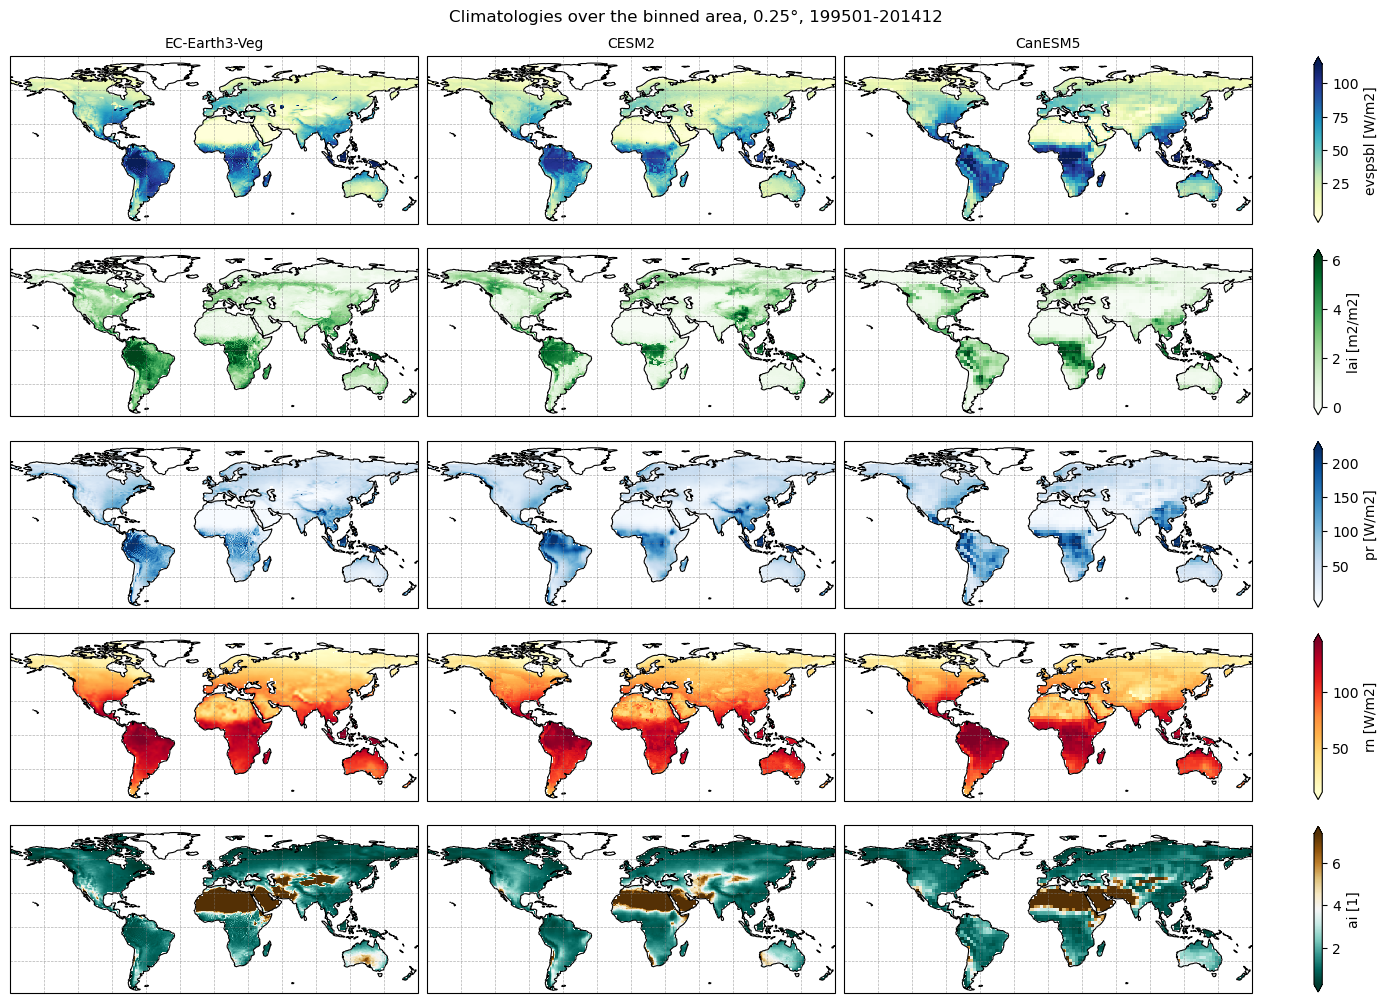

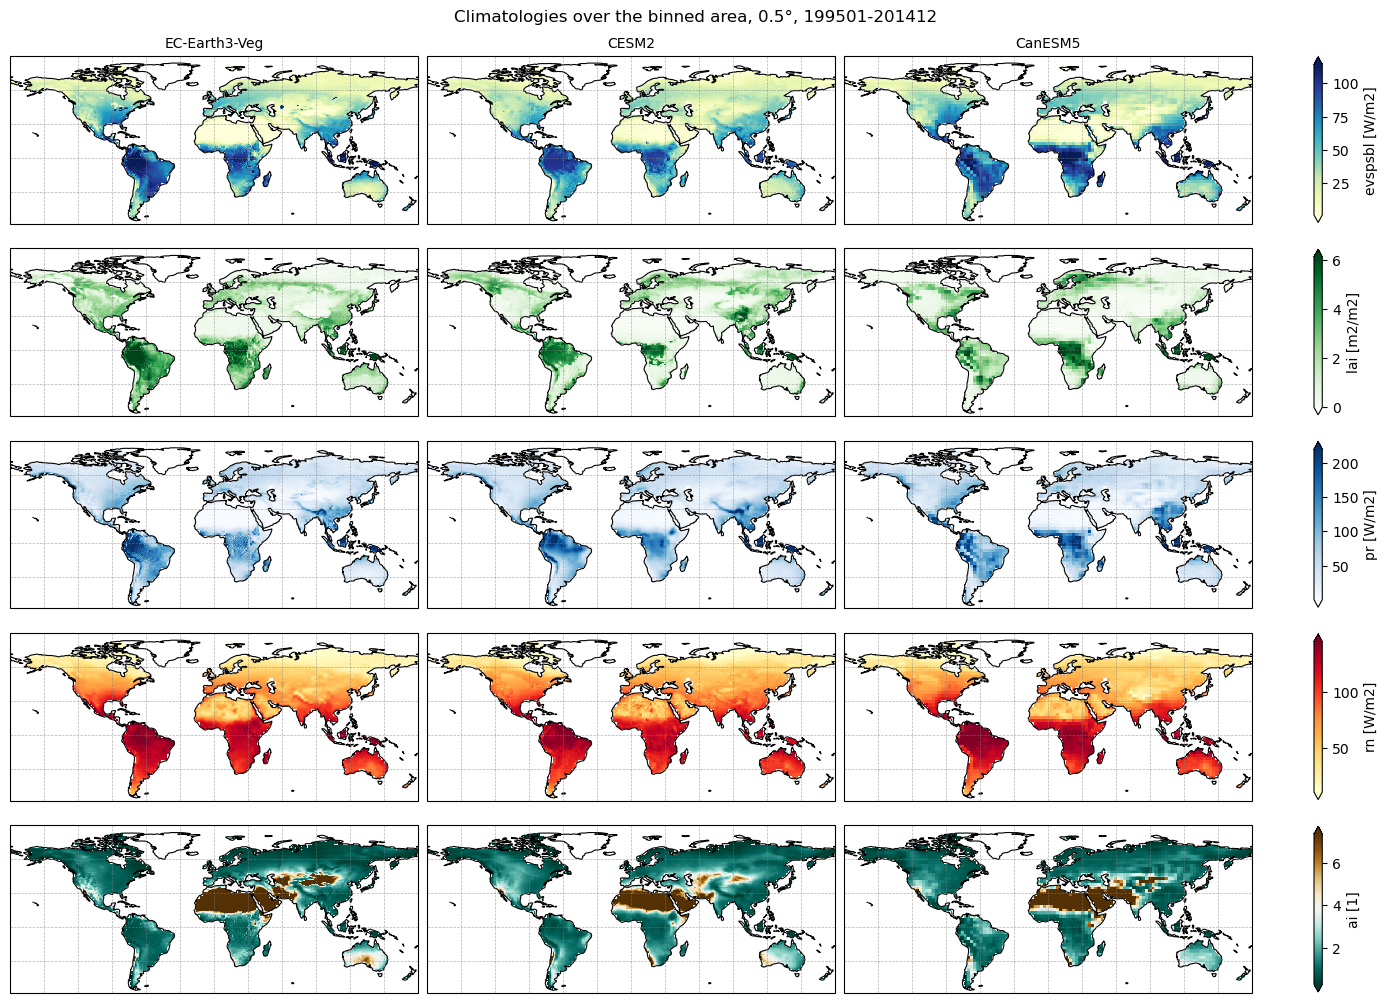

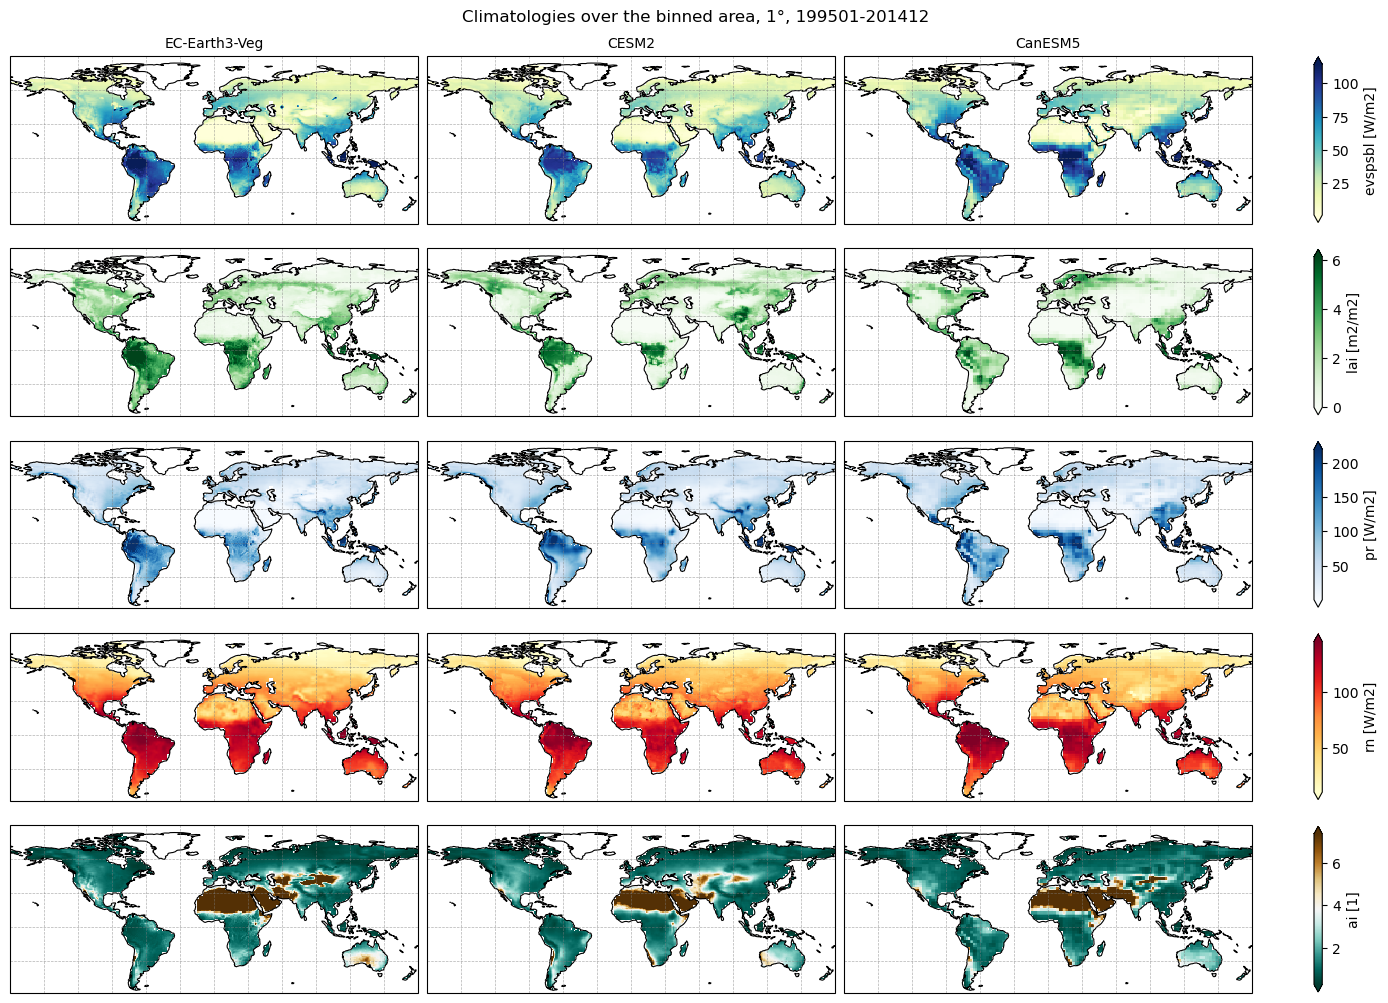

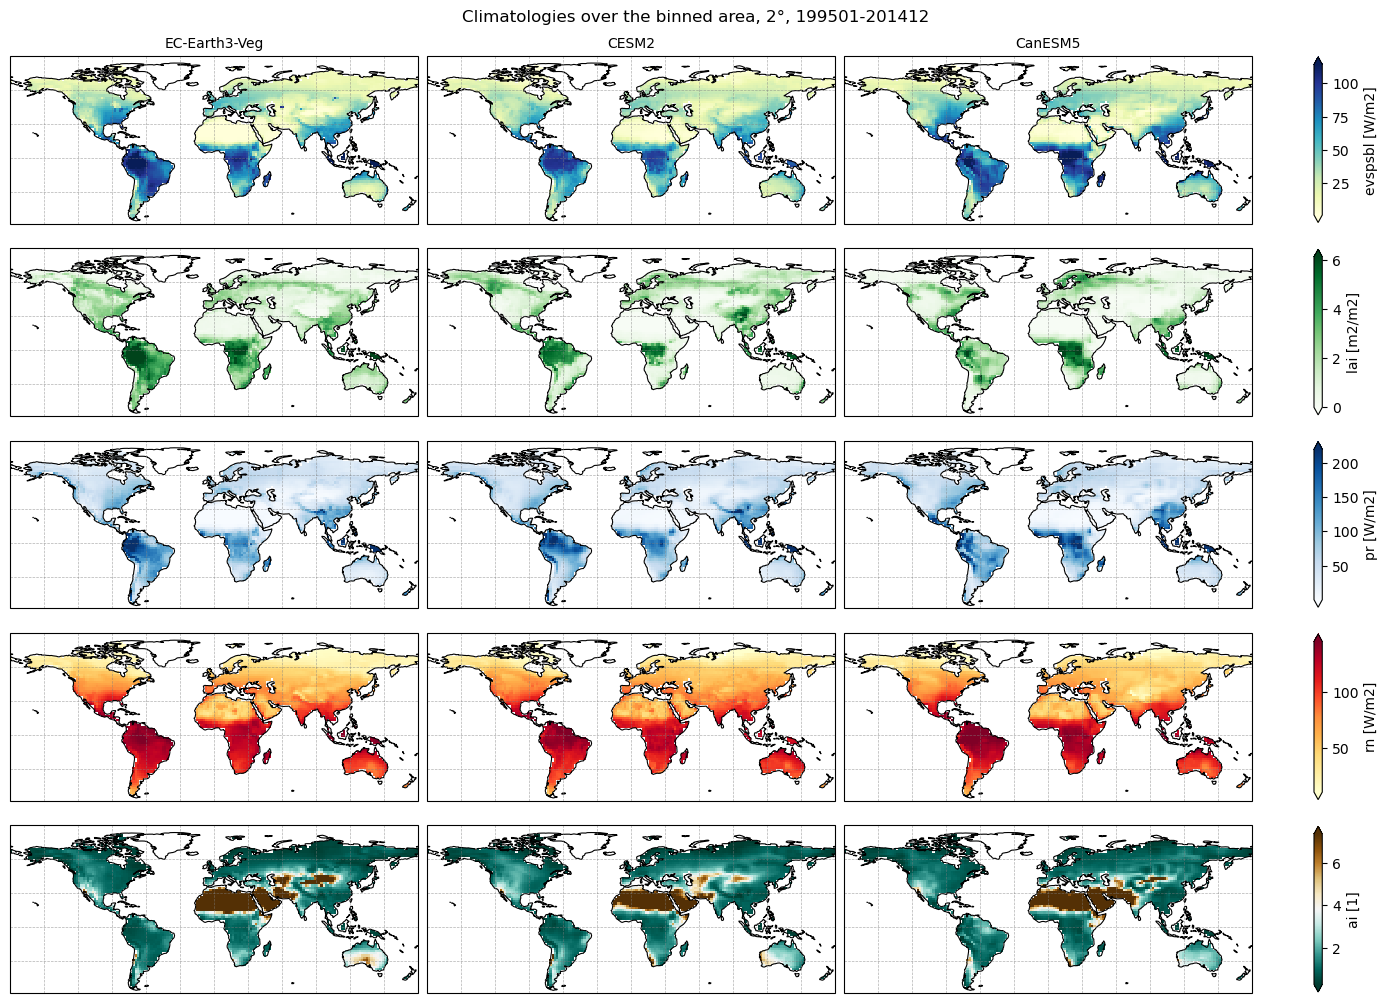

In [7]:
MAP_VARS = ["evspsbl", "lai", "pr", "rn", "ai"]
UNITS = {v: results["native"]["clim"][SOURCE_IDS[0]][v].attrs.get("units", "?") for v in MAP_VARS}

# Color limits from percentiles of all native fields pooled (AI is heavy-tailed)
CLIM_LIMS = {}
for v in MAP_VARS:
    vals = np.concatenate([binning.finite_flat(results["native"]["clim"][sid][v]) for sid in SOURCE_IDS])
    CLIM_LIMS[v] = np.percentile(vals, [2, 90] if v == "ai" else [2, 98])


def plot_clim_maps(label: str):
    clim = results[label]["clim"]
    fig, axs = plt.subplots(
        len(MAP_VARS), len(SOURCE_IDS), figsize=(4.6 * len(SOURCE_IDS), 2.0 * len(MAP_VARS)),
        layout="constrained", subplot_kw={"projection": config.PROJECTION},
    )
    for i, v in enumerate(MAP_VARS):
        vmin, vmax = CLIM_LIMS[v]
        for j, sid in enumerate(SOURCE_IDS):
            ax = axs[i, j]
            im = clim[sid][v].plot.pcolormesh(
                ax=ax, transform=ccrs.PlateCarree(), vmin=vmin, vmax=vmax,
                cmap=plotting.MAP_KWARGS[v]["cmap"], add_colorbar=False,
            )
            plotting.map_ax(ax, config.LAT_BNDS)
            ax.set_title(sid if i == 0 else "", fontsize=10)
        fig.colorbar(im, ax=axs[i, :], shrink=0.9, extend="both", label=f"{v} [{UNITS[v]}]")
    fig.suptitle(f"Climatologies over the binned area, {label}, {PERIOD}")
    plt.show()


for label in results:
    plot_clim_maps(label)

### Histograms of the binned gridcell-years

These are the distributions of climatological LAI and AI over the samples that get binned. Each gridcell
counts once per year with valid ET. The dashed lines are the pooled quantile edges. AI is shown as log10(AI)
because of its long tail; the few cells with AI ≤ 0 (Rn ≤ 0) are left out of that panel. The x-range is the
same at every resolution, so the panels can be compared directly.

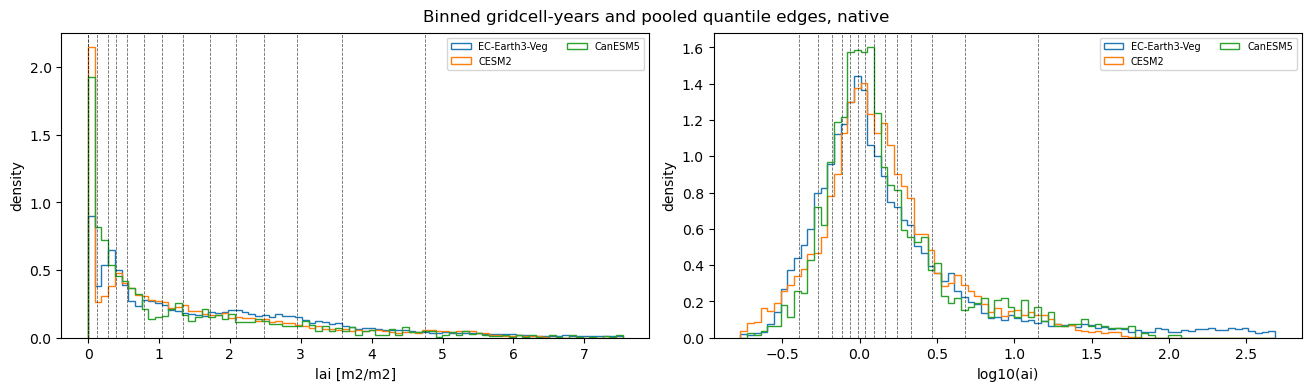

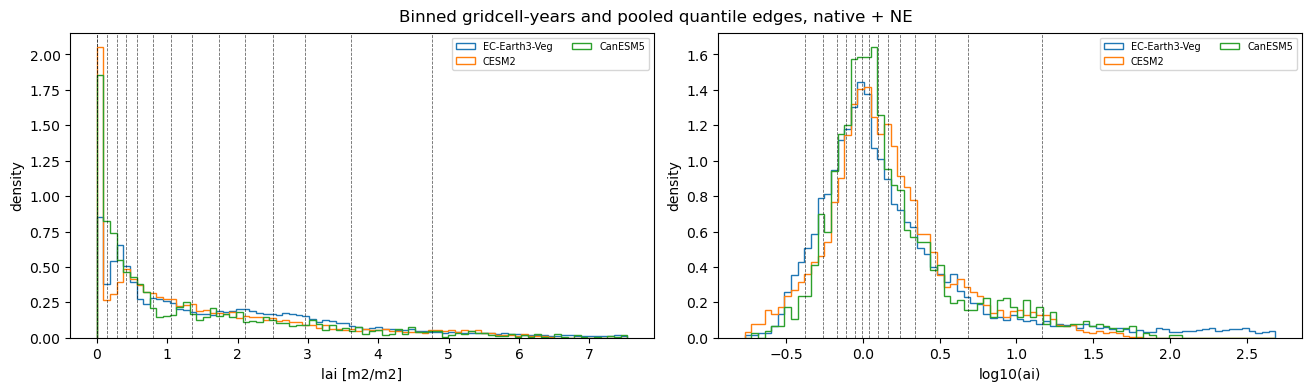

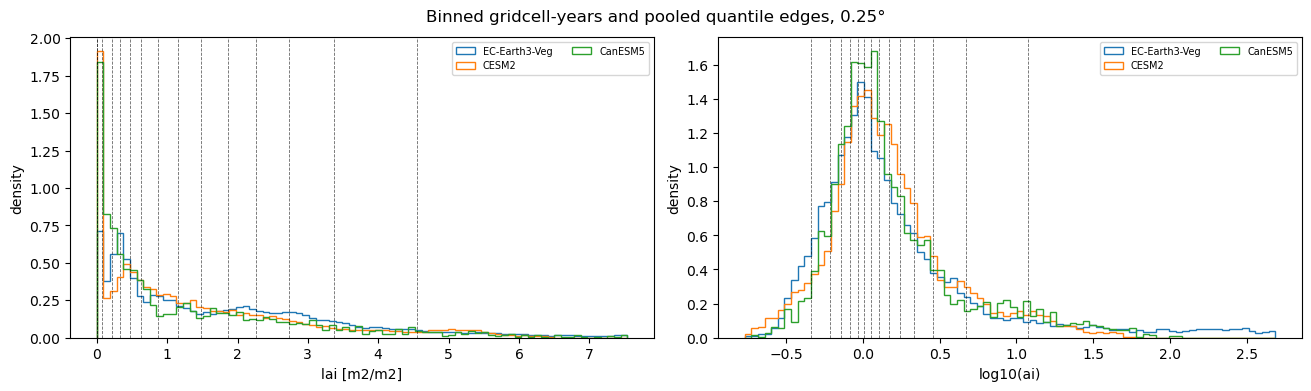

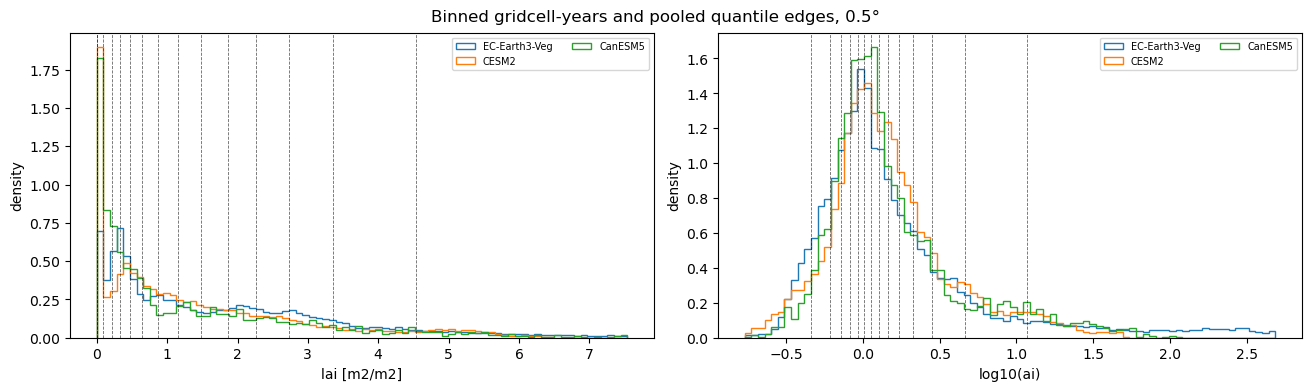

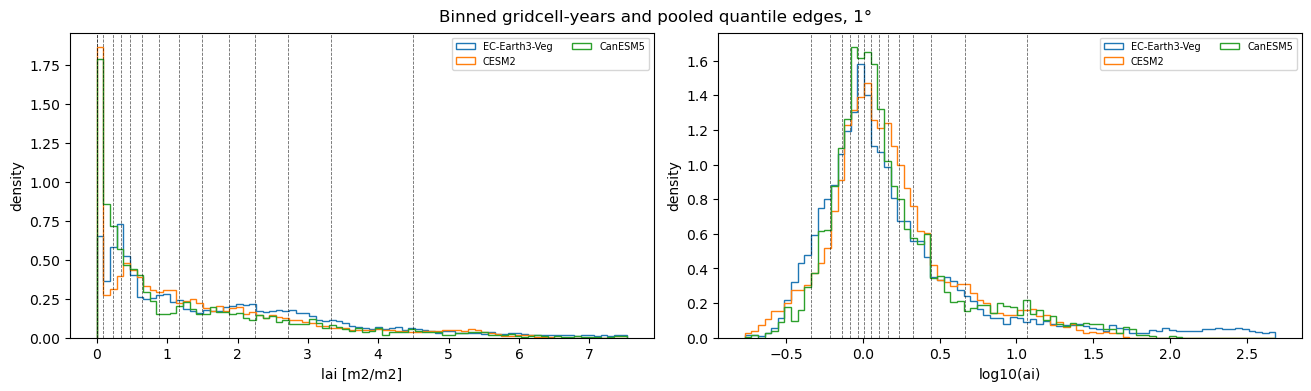

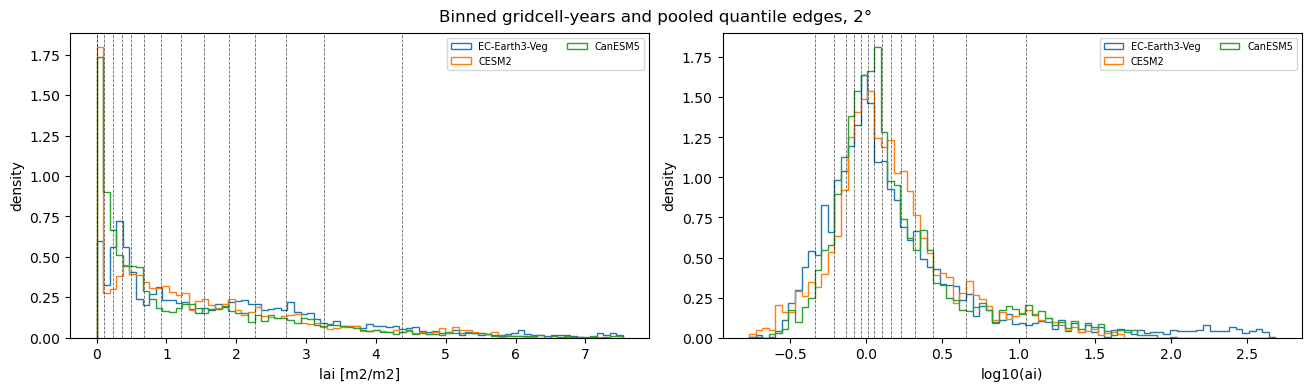

In [8]:
def gridcell_years(inputs: dict, v: str) -> xr.DataArray:
    # Climatological field repeated over the years with valid ET: one value per binned sample
    return inputs[v].broadcast_like(inputs["et"]).where(inputs["et"].notnull())


# AI on a log10 scale; nonpositive AI (and edges) become NaN and are skipped
TRANSFORM = {"lai": lambda x: x, "ai": lambda x: np.log10(x.where(x > 0))}
XLABEL = {"lai": "lai [m2/m2]", "ai": "log10(ai)"}

# Common x-range from the native samples: LAI 0 to 99.5th percentile, log10(AI) 0.5th to 99.5th
HIST_RANGE = {}
for v in ("lai", "ai"):
    vals = np.concatenate([binning.finite_flat(TRANSFORM[v](results["native"]["inputs"][sid][v])) for sid in SOURCE_IDS])
    HIST_RANGE[v] = (0.0 if v == "lai" else float(np.quantile(vals, 0.005)), float(np.quantile(vals, 0.995)))

for label, r in results.items():
    fig, axs = plt.subplots(1, 2, figsize=(13, 3.8), layout="constrained")
    for ax, v in zip(axs, ("lai", "ai")):
        plotting.plot_input_hist(
            {sid: TRANSFORM[v](gridcell_years(r["inputs"][sid], v)) for sid in SOURCE_IDS},
            TRANSFORM[v](r["edges"][v]), bins=80, value_range=HIST_RANGE[v], ax=ax,
        )
        ax.set_xlabel(XLABEL[v])
    fig.suptitle(f"Binned gridcell-years and pooled quantile edges, {label}")
    plt.show()

### Quantile edges

Thin colored lines are each model's own edges. The thick black line is the pooled edges used for binning.
The last edge (the maximum) is left out, as in `plot_model_edges` of `scripts/bin_cmip.py`. A model whose line sits far from the
pooled line will have its samples crowded into a few bins.

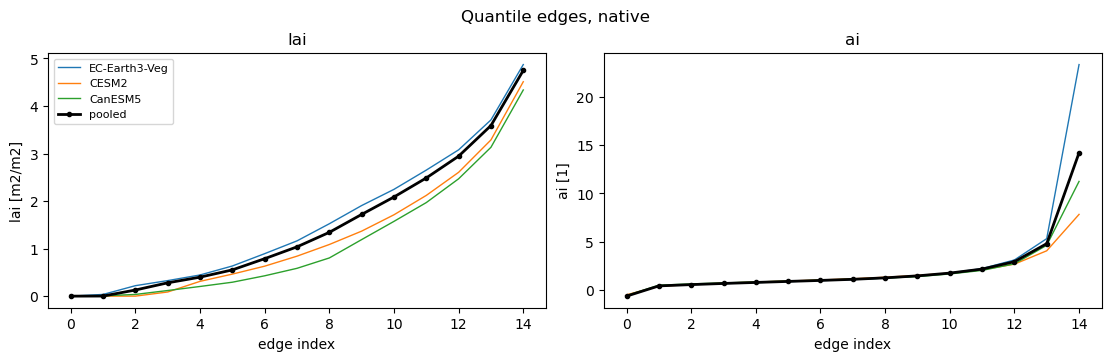

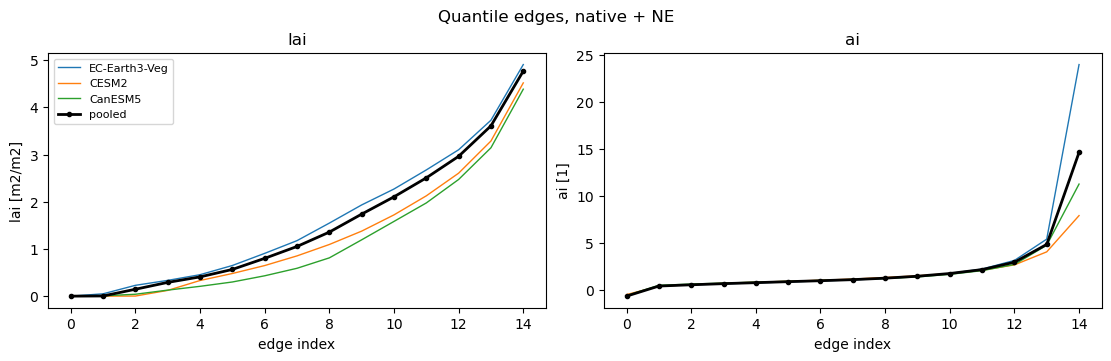

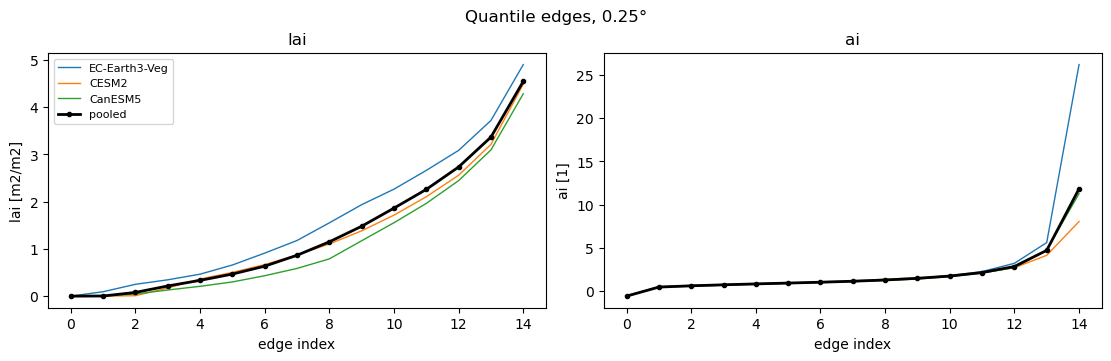

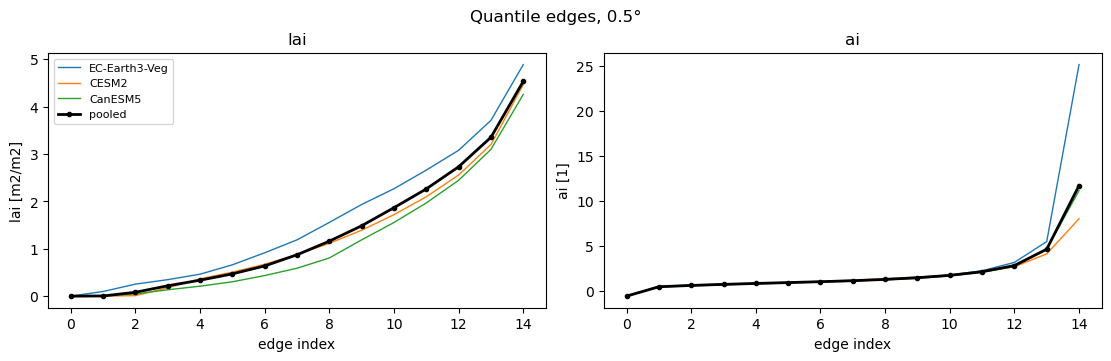

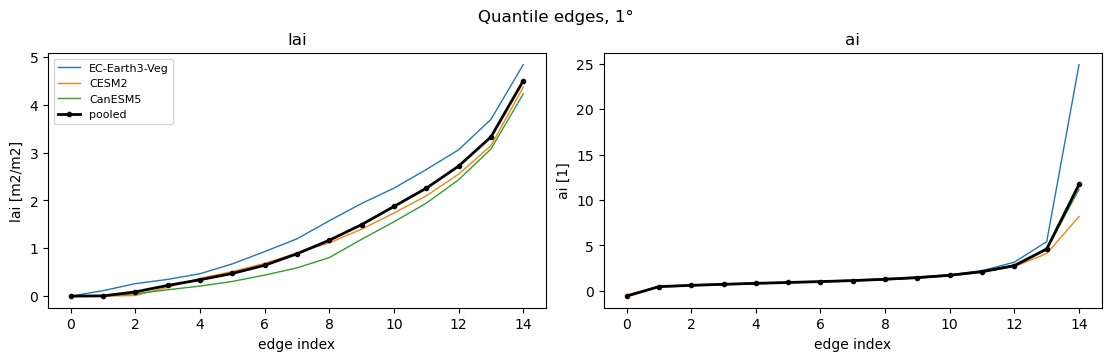

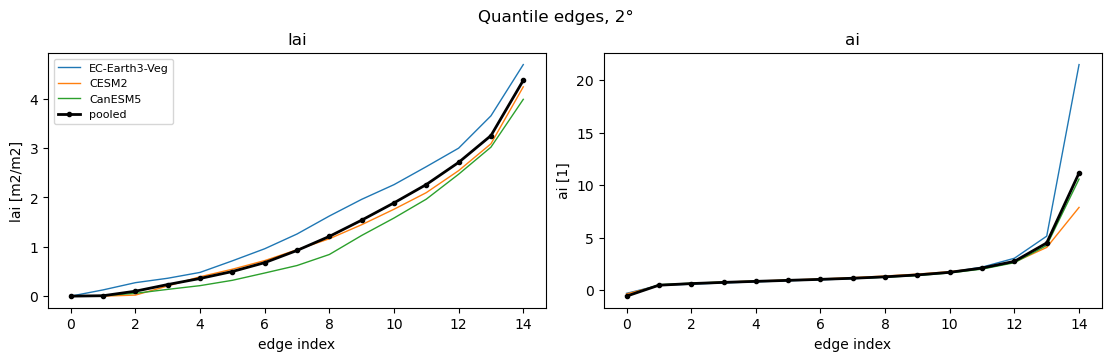

In [9]:
def plot_edges_ax(ax, model_edges: dict, pooled: xr.DataArray):
    idx = pooled.edge.values[:-1]
    for sid, e in model_edges.items():
        ax.plot(idx, e.values[:-1], color=COLORS[sid], lw=1, label=sid)
    ax.plot(idx, pooled.values[:-1], color="k", lw=2, marker="o", ms=3, label="pooled")
    ax.set_xlabel("edge index")
    ax.set_ylabel(f"{pooled.name} [{pooled.attrs.get('units', '?')}]")


for label, r in results.items():
    fig, axs = plt.subplots(1, 2, figsize=(11, 3.5), layout="constrained")
    for ax, v in zip(axs, ("lai", "ai")):
        plot_edges_ax(ax, r["model_edges"][v], r["edges"][v])
        ax.set_title(v)
    axs[0].legend(fontsize=8)
    fig.suptitle(f"Quantile edges, {label}")
    plt.show()

### Binned ET

These are the bin means with the pooled edges, as in the script's `bin_mean` figure. Zero-width bins (from
tied quantile edges) are dropped. Ticks show the edge values, so the axes change between resolutions.

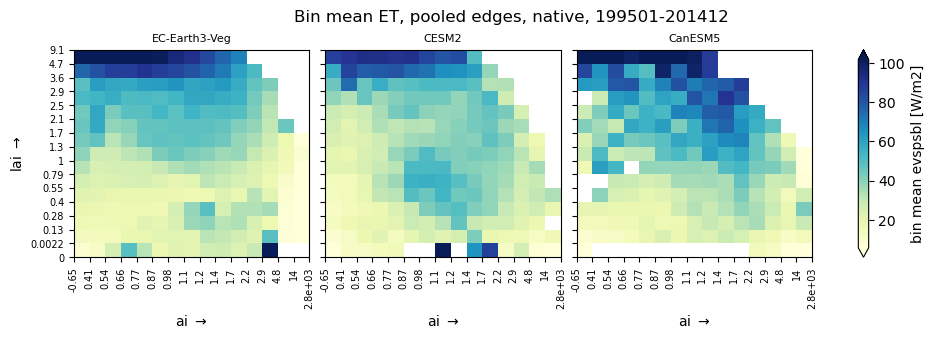

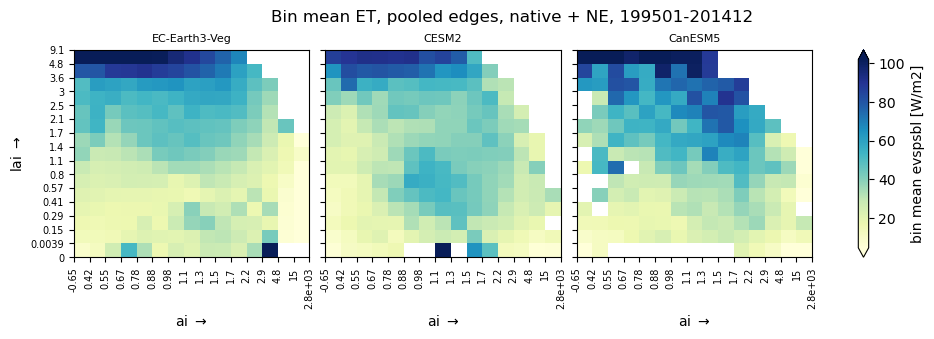

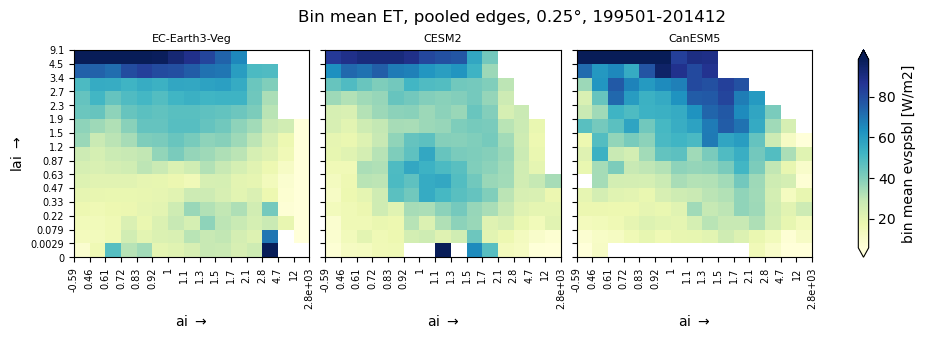

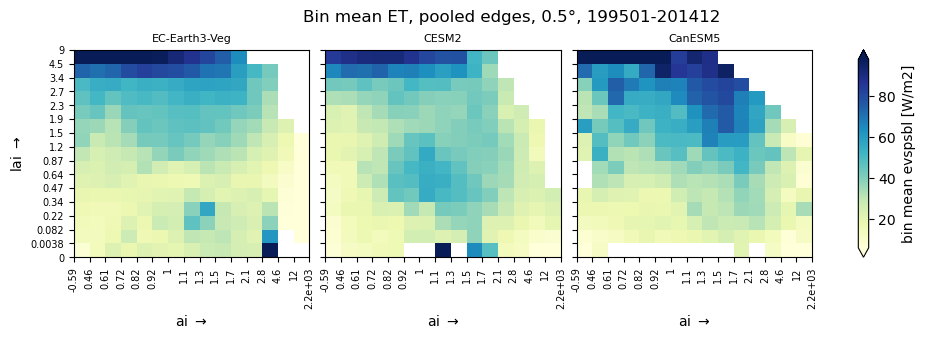

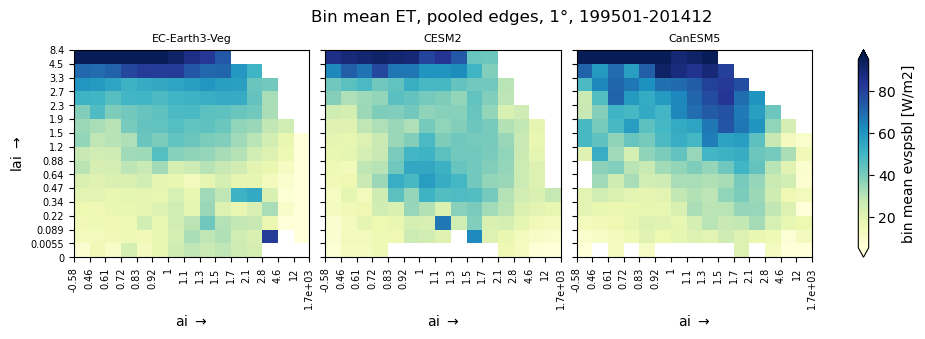

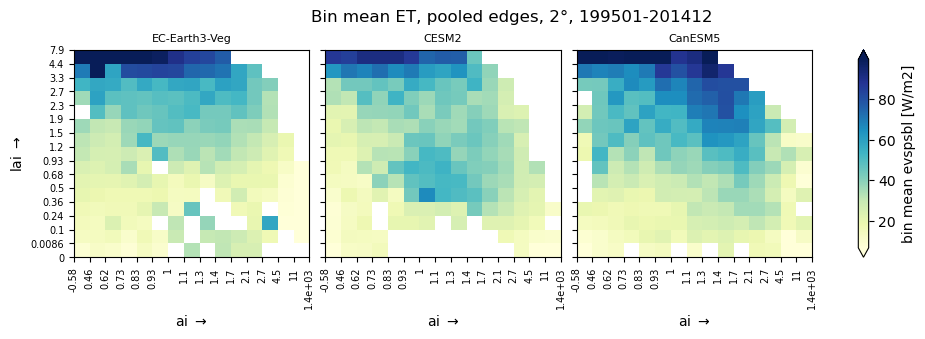

In [10]:
for label, r in results.items():
    plotting.plot_bin_means(
        binning.drop_zero_width_bins(r["bs"]), "source_id", title=f"Bin mean ET, pooled edges, {label}, {PERIOD}",
    )
    plt.show()

## Comparison across resolutions

There are two native references. **native** uses the native sftlf mask only. **native + NE** adds the Natural
Earth mask, so its area is closer to the regridded grids' area. It still has no common area across models and
no `na_thres` coastal loss; compare the areas in the summary table.

### Pooled edges

If regridding were neutral, every line would match the native ones (dashed). Coarser grids smooth the
extremes, so expect their upper LAI and AI edges to come down.

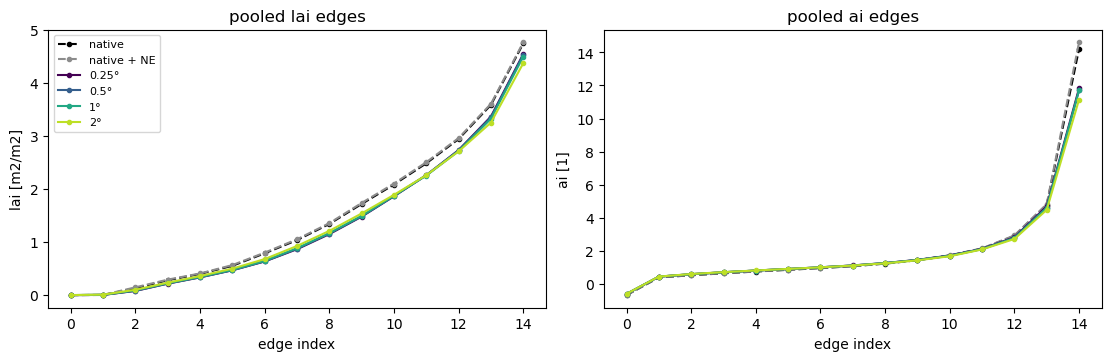

edge,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
lai edges,,,,,,,,,,,,,,,,
native,0.0,0.002,0.129,0.280,0.399,0.552,0.788,1.037,1.342,1.719,2.086,2.486,2.944,3.588,4.748,9.060
native + NE,0.0,0.004,0.146,0.291,0.408,0.566,0.801,1.053,1.357,1.738,2.104,2.506,2.962,3.608,4.768,9.060
0.25°,0.0,0.003,0.079,0.216,0.334,0.468,0.634,0.866,1.150,1.480,1.864,2.260,2.735,3.368,4.548,9.060
0.5°,0.0,0.004,0.082,0.219,0.337,0.470,0.638,0.873,1.161,1.486,1.867,2.264,2.731,3.354,4.535,9.012
1°,0.0,0.005,0.089,0.224,0.342,0.474,0.645,0.885,1.168,1.495,1.874,2.255,2.717,3.326,4.499,8.393
2°,0.0,0.009,0.100,0.235,0.358,0.499,0.679,0.926,1.211,1.540,1.890,2.262,2.711,3.254,4.375,7.946


edge,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
ai edges,,,,,,,,,,,,,,,,
native,-0.655,0.408,0.541,0.661,0.767,0.872,0.975,1.090,1.244,1.448,1.735,2.151,2.919,4.788,14.204,2802.809
native + NE,-0.655,0.418,0.552,0.672,0.777,0.883,0.984,1.099,1.256,1.461,1.749,2.167,2.948,4.840,14.607,2802.809
0.25°,-0.590,0.460,0.606,0.723,0.827,0.923,1.023,1.135,1.280,1.472,1.735,2.139,2.839,4.707,11.828,2802.809
0.5°,-0.586,0.457,0.605,0.721,0.825,0.921,1.020,1.131,1.275,1.462,1.724,2.127,2.813,4.633,11.707,2249.121
1°,-0.582,0.460,0.608,0.725,0.827,0.922,1.020,1.130,1.276,1.459,1.714,2.120,2.781,4.611,11.713,1744.302
2°,-0.578,0.463,0.618,0.732,0.830,0.926,1.021,1.127,1.263,1.443,1.691,2.101,2.734,4.490,11.149,1390.610


In [11]:
res_colors = dict(zip([LABELS[r] for r in REGRIDDED], plt.get_cmap("viridis")(np.linspace(0, 0.9, len(REGRIDDED)))))
res_colors.update({LABELS["native"]: "k", REF: "0.55"})

fig, axs = plt.subplots(1, 2, figsize=(11, 3.5), layout="constrained")
for ax, v in zip(axs, ("lai", "ai")):
    for res in RESOLUTIONS:
        label = LABELS[res]
        e = results[label]["edges"][v]
        ax.plot(e.edge[:-1], e[:-1], color=res_colors[label], ls="--" if res in NATIVE else "-",
                marker="o", ms=3, label=label)
    ax.set_xlabel("edge index")
    ax.set_ylabel(f"{v} [{binning.EDGE_ATTRS[v]['units']}]")
    ax.set_title(f"pooled {v} edges")
axs[0].legend(fontsize=8)
plt.show()

# The same edges as a table (rows: resolution)
for v in ("lai", "ai"):
    display(pd.DataFrame({label: r["edges"][v].values for label, r in results.items()}).T.round(3)
            .rename_axis(index=f"{v} edges", columns="edge"))

### Bin mean ET by quantile bin

Rows are models and columns are resolutions, all on one color scale. Bins are indexed by quantile rather than
value, so the same cell is the same quantile range in every panel. Zero-width bins are kept and appear empty.

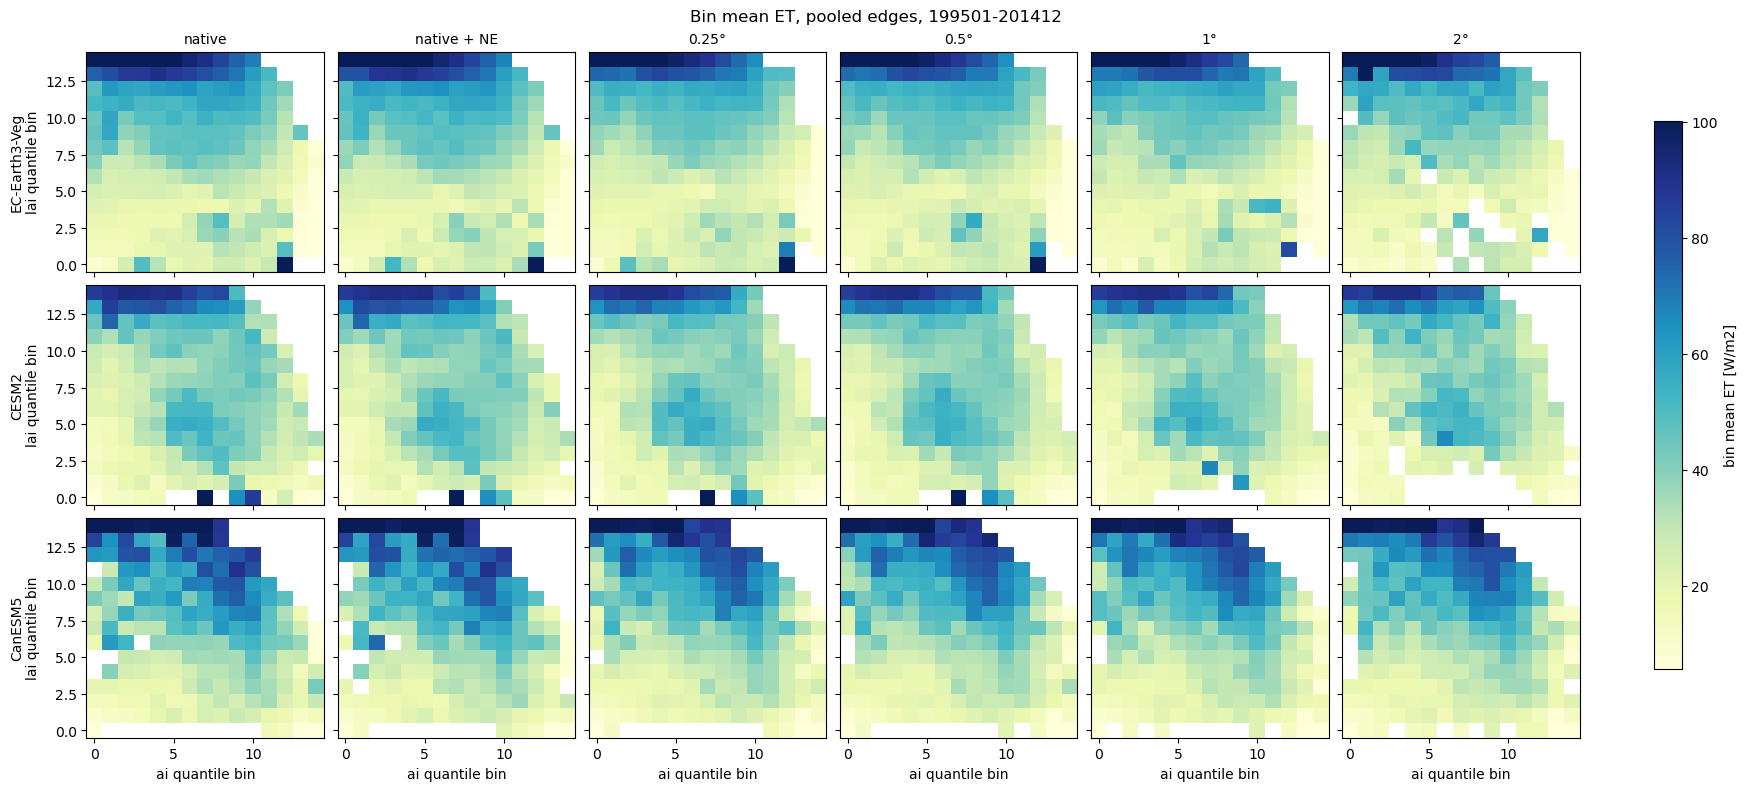

In [12]:
def bin_mean(label: str, sid: str, key: str = "bs") -> xr.DataArray:
    # (y_bin, x_bin) bin mean; edge coords dropped so that resolutions can be differenced by bin index
    return results[label][key].sel(source_id=sid, stats="mean").reset_coords(drop=True)


def bin_grid(fields: dict, title: str, cbar_label: str, **kwargs):
    # One heatmap per (model, resolution) in `fields`, shared color scale
    cols = list(next(iter(fields.values())))
    fig, axs = plt.subplots(
        len(fields), len(cols), figsize=(2.9 * len(cols), 2.6 * len(fields)),
        sharex=True, sharey=True, layout="constrained", squeeze=False,
    )
    for i, (sid, row) in enumerate(fields.items()):
        for j, (label, da) in enumerate(row.items()):
            ax = axs[i, j]
            im = da.plot.pcolormesh(ax=ax, x="x_bin", y="y_bin", add_colorbar=False, add_labels=False, **kwargs)
            ax.set_title(label if i == 0 else "", fontsize=10)
        axs[i, 0].set_ylabel(f"{sid}\nlai quantile bin")
    for ax in axs[-1, :]:
        ax.set_xlabel("ai quantile bin")
    fig.colorbar(im, ax=axs, shrink=0.8, label=cbar_label)
    fig.suptitle(title)
    plt.show()


units = results["native"]["bs"].attrs.get("units", "W/m2")
means = {sid: {label: bin_mean(label, sid) for label in results} for sid in SOURCE_IDS}
vmin, vmax = np.nanpercentile(np.concatenate([m.values.ravel() for row in means.values() for m in row.values()]), [2, 98])
bin_grid(means, f"Bin mean ET, pooled edges, {PERIOD}", f"bin mean ET [{units}]", cmap="YlGnBu", vmin=vmin, vmax=vmax)

### Fixed edges

Each regridded grid is binned again with the native + NE pooled edges. Per bin, the difference from
native + NE then splits exactly into two parts:

$$
\underbrace{\text{regridded}_\text{own edges} - \text{native+NE}}_\text{total}
= \underbrace{\text{regridded}_\text{fixed edges} - \text{native+NE}}_\text{sample effect}
+ \underbrace{\text{regridded}_\text{own edges} - \text{regridded}_\text{fixed edges}}_\text{edge effect}
$$

- **Sample effect**: the edges are the same and the samples changed (smoothing, binned area).
- **Edge effect**: the samples are the same and the pooled edges moved, because every model's distribution changed.

Samples outside the fixed edges are clipped into the outer bins, as `be.bin_stats` always does.

In [13]:
for res in REGRIDDED:
    r = results[LABELS[res]]
    r["bs_fixed"] = bin_models(r["inputs"], results[REF]["edges"], LABELS[res])

### Differences from native

Each figure has models in rows and regridded resolutions in columns. All four figures share one color scale.
The first figure is the comparison from the first version of this notebook. The other three are the
native + NE comparison and its two parts.

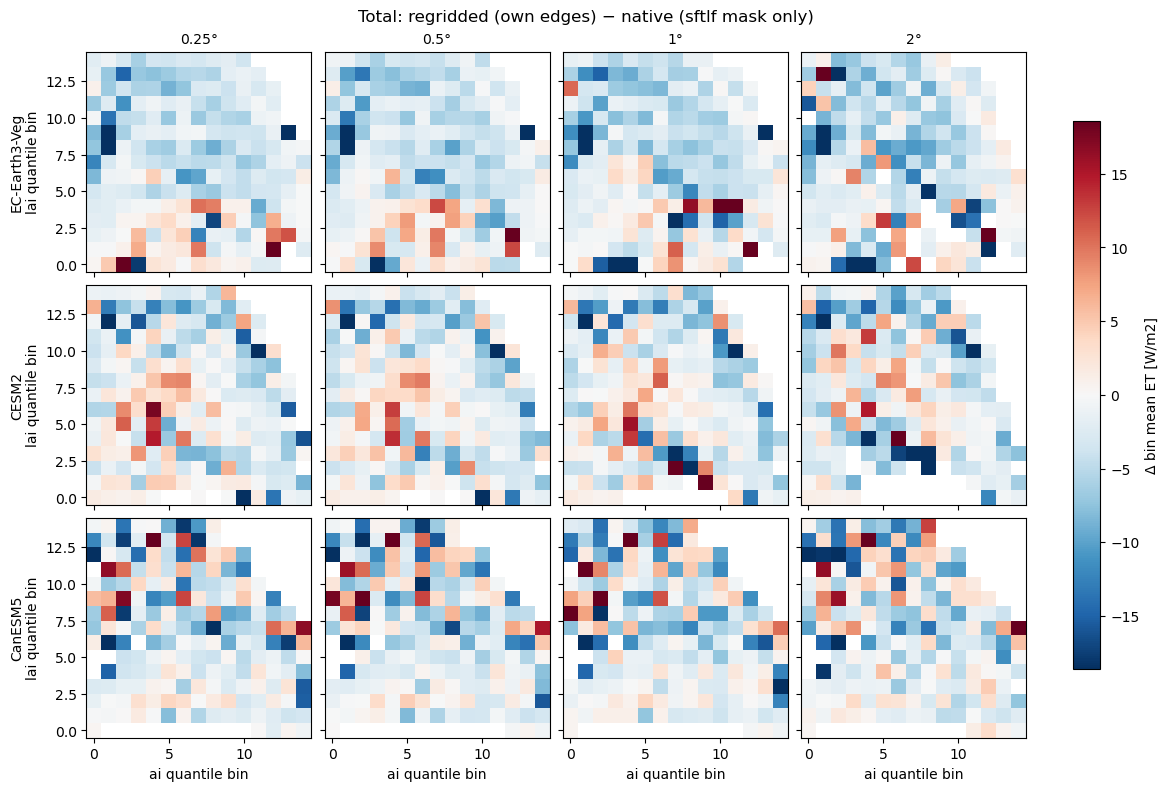

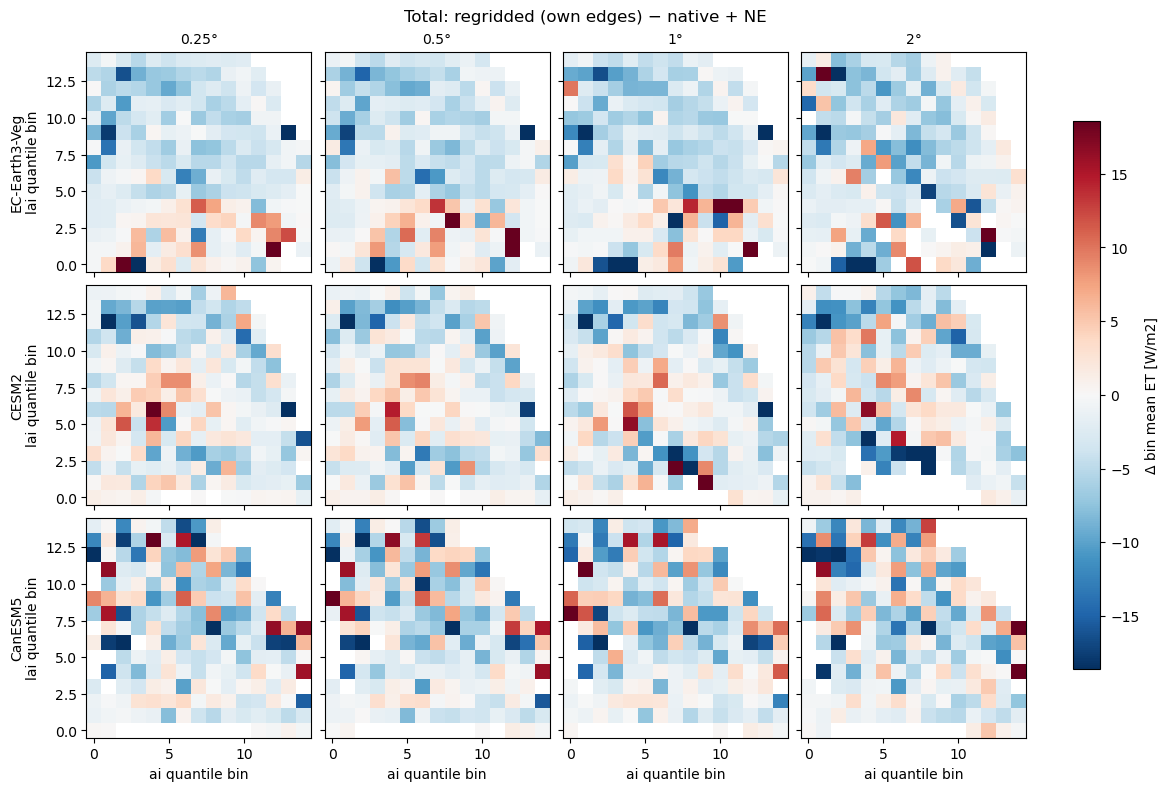

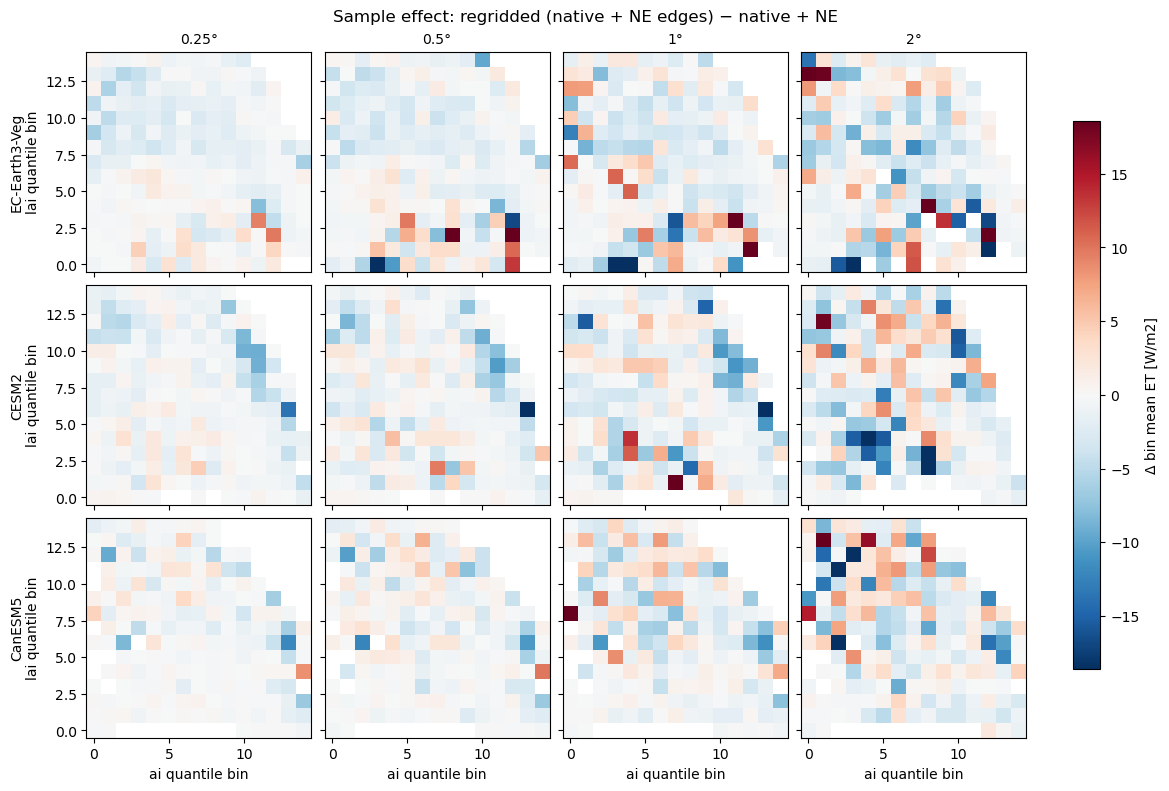

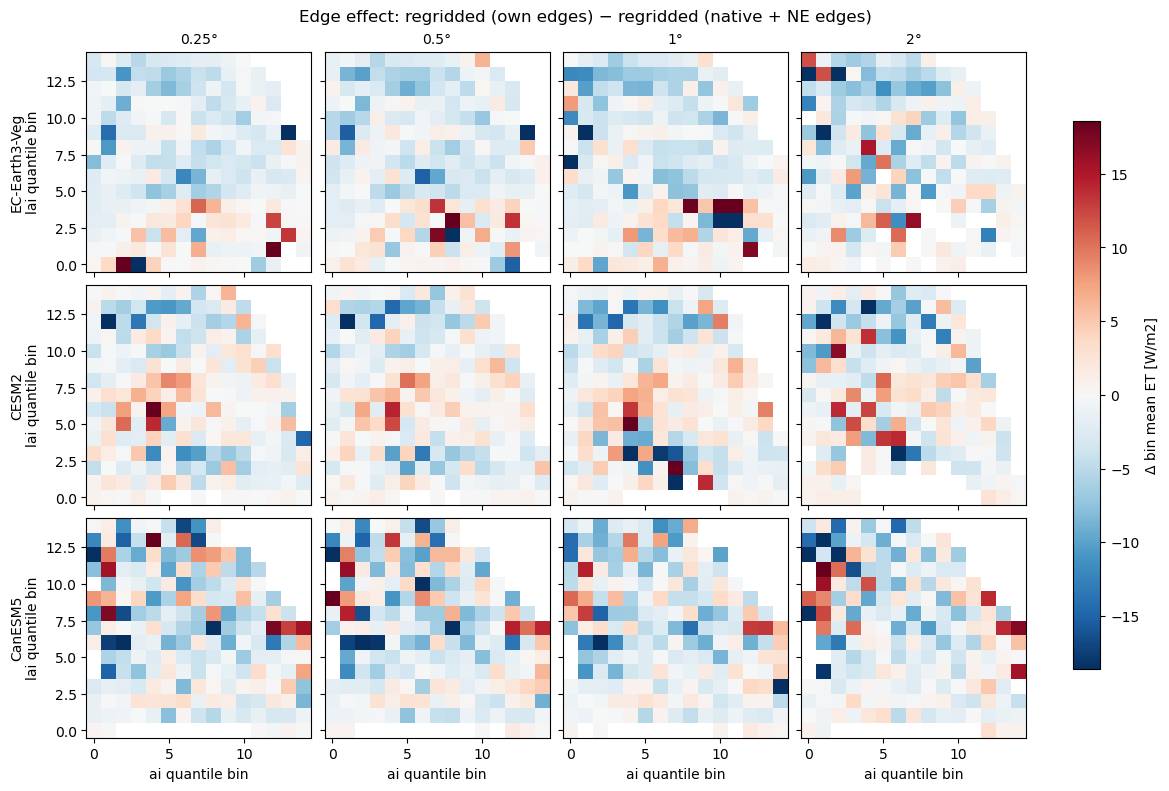

In [14]:
REG_LABELS = [LABELS[r] for r in REGRIDDED]
DIFFS = {  # name: (function of (label, sid), figure title)
    "total vs native": (
        lambda label, sid: bin_mean(label, sid) - bin_mean("native", sid),
        "Total: regridded (own edges) − native (sftlf mask only)"),
    "total vs native + NE": (
        lambda label, sid: bin_mean(label, sid) - bin_mean(REF, sid),
        "Total: regridded (own edges) − native + NE"),
    "sample effect": (
        lambda label, sid: bin_mean(label, sid, "bs_fixed") - bin_mean(REF, sid),
        "Sample effect: regridded (native + NE edges) − native + NE"),
    "edge effect": (
        lambda label, sid: bin_mean(label, sid) - bin_mean(label, sid, "bs_fixed"),
        "Edge effect: regridded (own edges) − regridded (native + NE edges)"),
}
diffs = {name: {sid: {label: f(label, sid) for label in REG_LABELS} for sid in SOURCE_IDS}
         for name, (f, _) in DIFFS.items()}

vals = np.concatenate([d.values.ravel() for dd in diffs.values() for row in dd.values() for d in row.values()])
lim = np.nanpercentile(np.abs(vals), 98)
for name, (_, title) in DIFFS.items():
    bin_grid(diffs[name], title, f"Δ bin mean ET [{units}]", cmap="RdBu_r", vmin=-lim, vmax=lim)

### Size of the differences versus resolution

These are the RMS and mean of each difference over bins that are non-empty in both fields. There is one
column per model, and the dotted line marks the model's native spacing. How to read it:
- *total vs native + NE* well below *total vs native*: the mask, not the resolution, drove the first version's jump.
- Sample effect near zero at fine resolutions and growing with coarsening: regridding itself matters only
  when it smooths.
- A large edge effect: the shared quantile edges carry a resolution effect into every model, even one
  that wasn't smoothed.

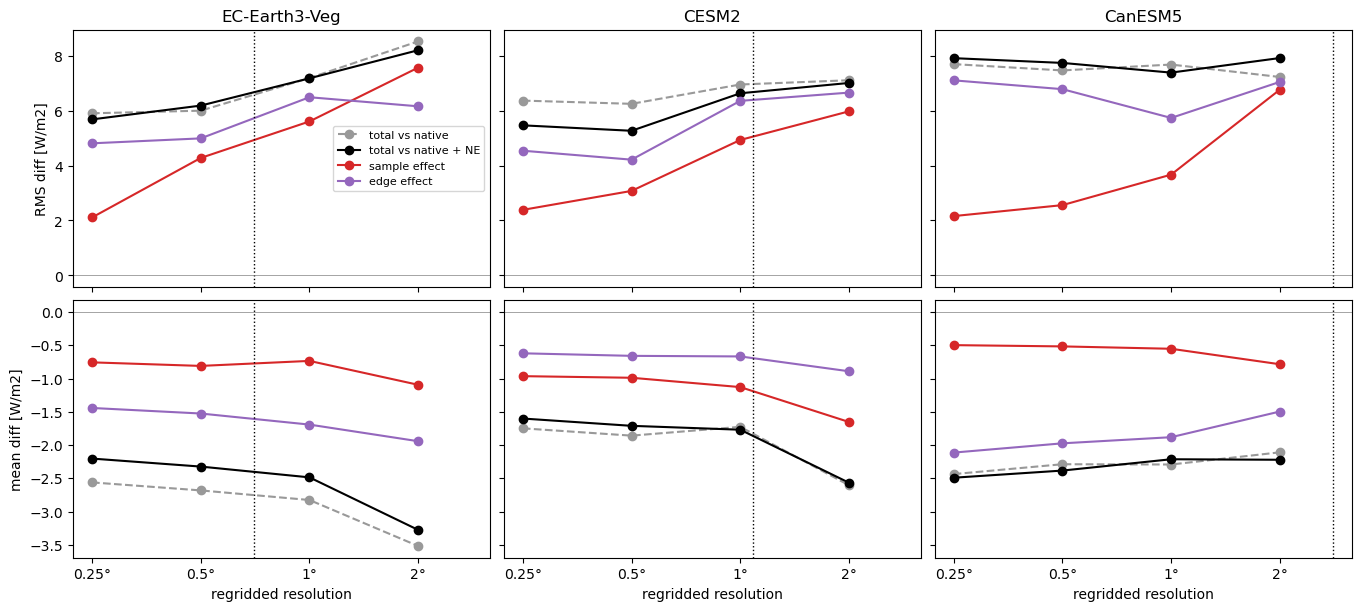

In [15]:
rows = []
for name, dd in diffs.items():
    for sid in SOURCE_IDS:
        for label, d in dd[sid].items():
            d = d.values[np.isfinite(d.values)]
            rows.append({"comparison": name, "source_id": sid, "resolution": label, "n bins": d.size,
                         "RMS diff": np.sqrt(np.mean(d**2)), "mean diff": np.mean(d)})
diff_stats = pd.DataFrame(rows)

res_deg = {LABELS[res]: res for res in REGRIDDED}
comp_style = {"total vs native": ("0.6", "--"), "total vs native + NE": ("k", "-"),
              "sample effect": ("C3", "-"), "edge effect": ("C4", "-")}
fig, axs = plt.subplots(2, len(SOURCE_IDS), figsize=(4.5 * len(SOURCE_IDS), 6), sharex=True, sharey="row",
                        layout="constrained")
for j, sid in enumerate(SOURCE_IDS):
    for i, stat in enumerate(("RMS diff", "mean diff")):
        ax = axs[i, j]
        for name, (color, ls) in comp_style.items():
            g = diff_stats[(diff_stats["comparison"] == name) & (diff_stats["source_id"] == sid)]
            ax.plot([res_deg[r] for r in g["resolution"]], g[stat], color=color, ls=ls, marker="o", label=name)
        # Native spacing: geometric mean of the lat and lon spacings
        ax.axvline(np.sqrt(np.prod(rg.approx_resolution(native[sid][2]))), color="k", ls=":", lw=1)
        ax.axhline(0, color="0.5", lw=0.5)
        ax.set_xscale("log", base=2)
        ax.set_xticks(list(res_deg.values()), list(res_deg))
        if j == 0:
            ax.set_ylabel(f"{stat} [{units}]")
    axs[0, j].set_title(sid)
    axs[-1, j].set_xlabel("regridded resolution")
axs[0, 0].legend(fontsize=8)
plt.show()

diff_stats.set_index(["source_id", "resolution", "comparison"])[["RMS diff", "mean diff"]].unstack("comparison").style.format(precision=2)